In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/content/telco_churn_cleaned.csv')

CHURN_PALETTE = {'Yes': '#E24B4A', 'No': '#1D9E75'}
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")

Loaded: 7043 rows, 22 columns


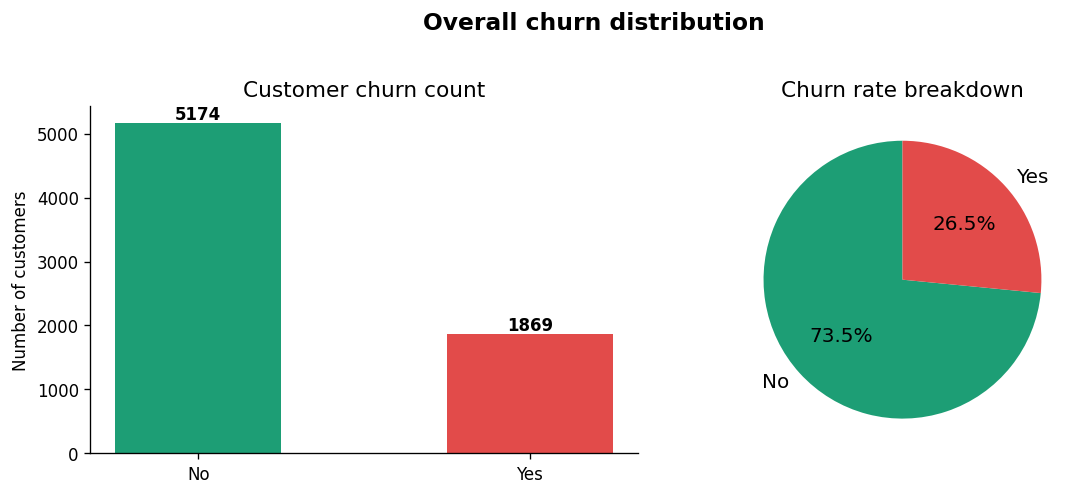

In [7]:
import os

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

churn_counts = df['Churn'].value_counts()

axes[0].bar(churn_counts.index, churn_counts.values,
            color=['#1D9E75', '#E24B4A'], width=0.5)
axes[0].set_title('Customer churn count', fontsize=13)
axes[0].set_ylabel('Number of customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

axes[1].pie(churn_counts.values, labels=churn_counts.index,
            colors=['#1D9E75', '#E24B4A'], autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Churn rate breakdown', fontsize=13)

plt.suptitle('Overall churn distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
os.makedirs('visuals', exist_ok=True)
plt.savefig('visuals/01_churn_distribution.png', bbox_inches='tight')
plt.show()

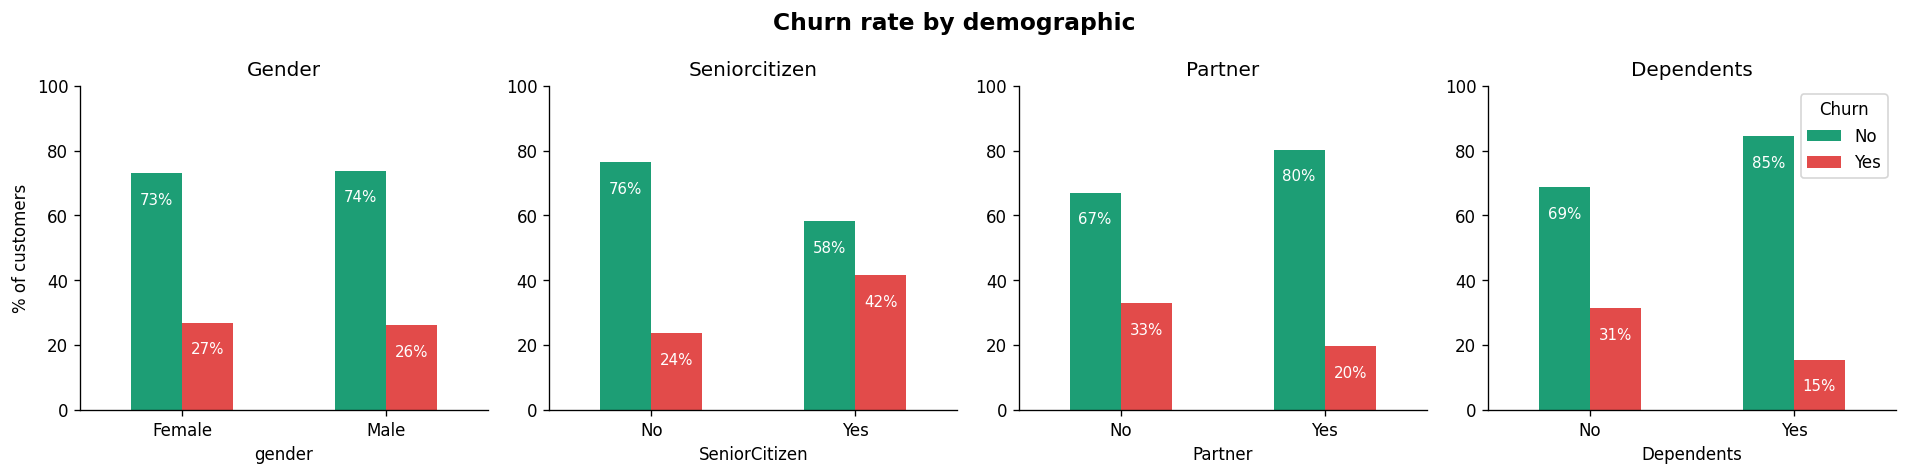

In [8]:
import os
demo_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, col in enumerate(demo_cols):
    churn_pct = df.groupby(col)['Churn'].value_counts(normalize=True).unstack() * 100
    churn_pct.plot(kind='bar', ax=axes[i], color=['#1D9E75', '#E24B4A'],
                   rot=0, legend=(i == 3))
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=12)
    axes[i].set_ylabel('% of customers' if i == 0 else '')
    axes[i].set_ylim(0, 100)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    for bar in axes[i].patches:
        h = bar.get_height()
        if h > 5:
            axes[i].text(bar.get_x() + bar.get_width()/2,
                         h - 6, f'{h:.0f}%',
                         ha='center', va='top', fontsize=9, color='white')

plt.suptitle('Churn rate by demographic', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('visuals/02_demographics_churn.png', bbox_inches='tight')
plt.show()

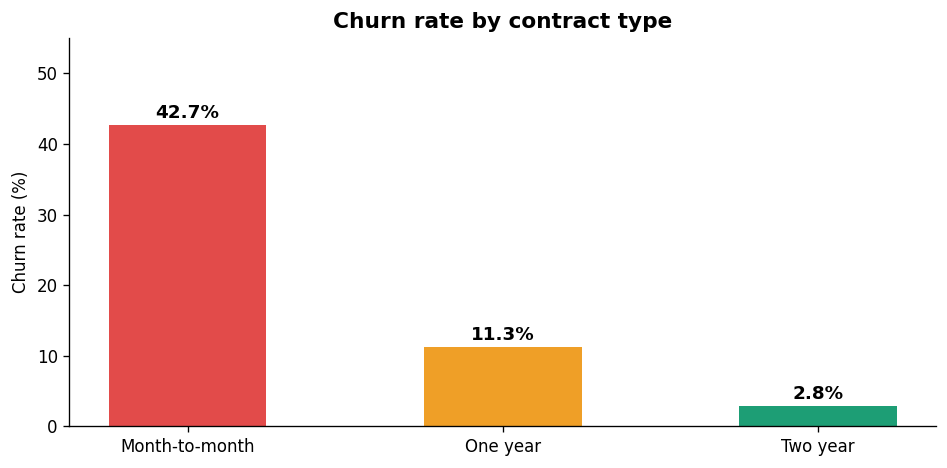

In [9]:
import os
fig, ax = plt.subplots(figsize=(8, 4))

contract_churn = df.groupby('Contract')['Churn_Binary'].mean() * 100
bars = ax.bar(contract_churn.index, contract_churn.values,
              color=['#E24B4A', '#EF9F27', '#1D9E75'], width=0.5)

ax.set_title('Churn rate by contract type', fontsize=13, fontweight='bold')
ax.set_ylabel('Churn rate (%)')
ax.set_ylim(0, 55)

for bar, val in zip(bars, contract_churn.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            val + 1, f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('visuals/03_contract_churn.png', bbox_inches='tight')
plt.show()

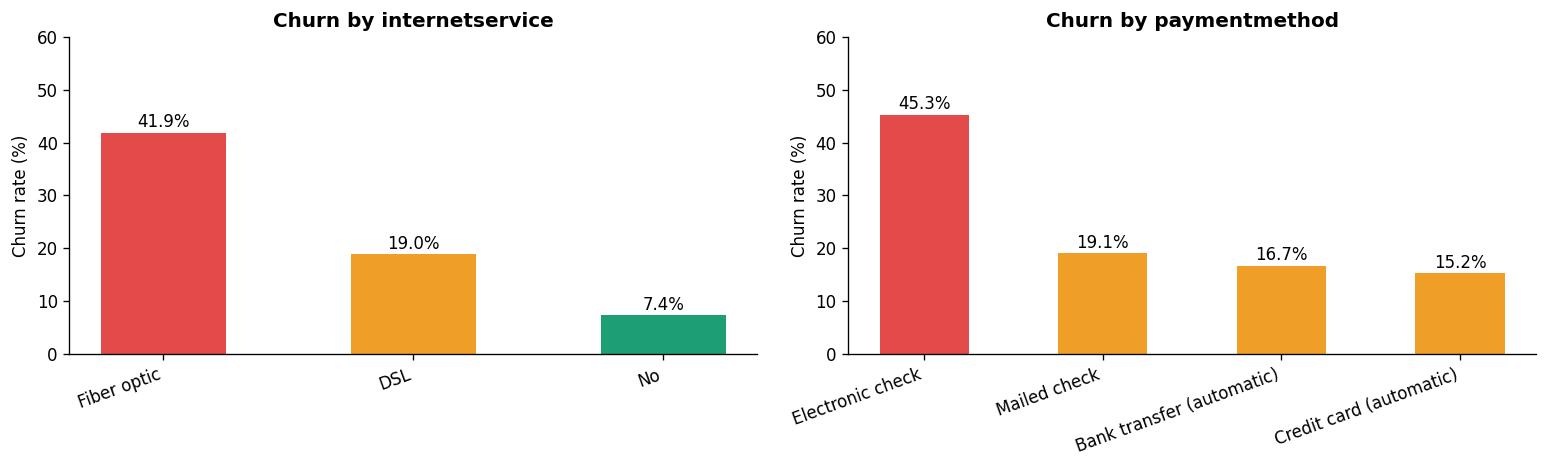

In [11]:
import os
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col in zip(axes, ['InternetService', 'PaymentMethod']):
    ct = df.groupby(col)['Churn_Binary'].mean().sort_values(ascending=False) * 100
    bars = ax.bar(range(len(ct)), ct.values,
                  color=['#E24B4A' if v > 30 else '#EF9F27' if v > 15 else '#1D9E75'
                         for v in ct.values], width=0.5)
    ax.set_xticks(range(len(ct)))
    ax.set_xticklabels(ct.index, rotation=20, ha='right', fontsize=10)
    ax.set_ylabel('Churn rate (%)')
    ax.set_title(f'Churn by {col.replace("_"," ").lower()}', fontsize=12, fontweight='bold')
    ax.set_ylim(0, 60)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for bar, val in zip(bars, ct.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                val + 1, f'{val:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('visuals/04_service_payment_churn.png', bbox_inches='tight')
plt.show()

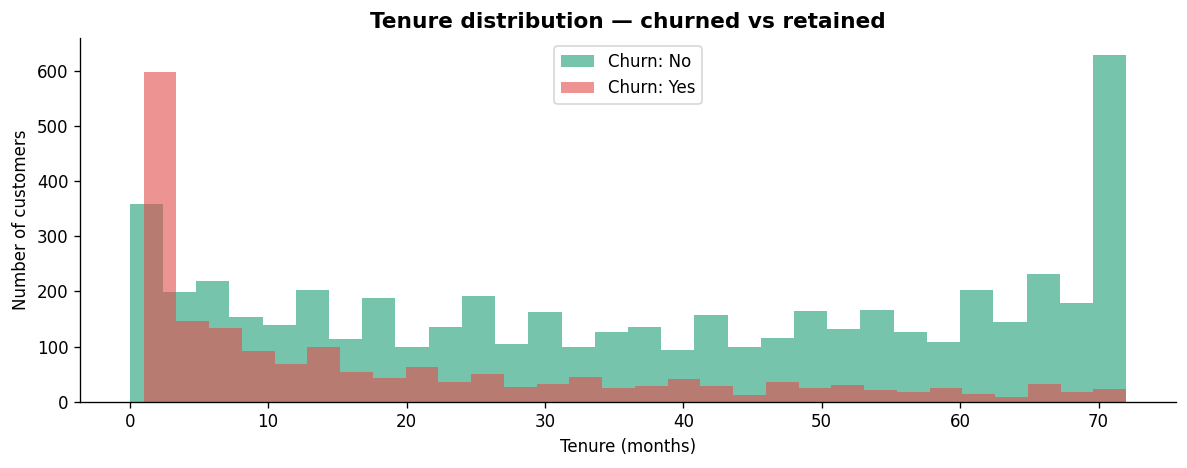

Average tenure - Churned: 18.0 months
Average tenure - Retained: 37.6 months


In [13]:
import os
fig, ax = plt.subplots(figsize=(10, 4))

for label, color in [('No', '#1D9E75'), ('Yes', '#E24B4A')]:
    subset = df[df['Churn'] == label]['tenure']
    ax.hist(subset, bins=30, alpha=0.6, color=color,
            label=f'Churn: {label}', edgecolor='none')

ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Number of customers')
ax.set_title('Tenure distribution — churned vs retained', fontsize=13, fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('visuals/05_tenure_distribution.png', bbox_inches='tight')
plt.show()

print("Average tenure - Churned:", round(df[df['Churn']=='Yes']['tenure'].mean(), 1), "months")
print("Average tenure - Retained:", round(df[df['Churn']=='No']['tenure'].mean(), 1), "months")

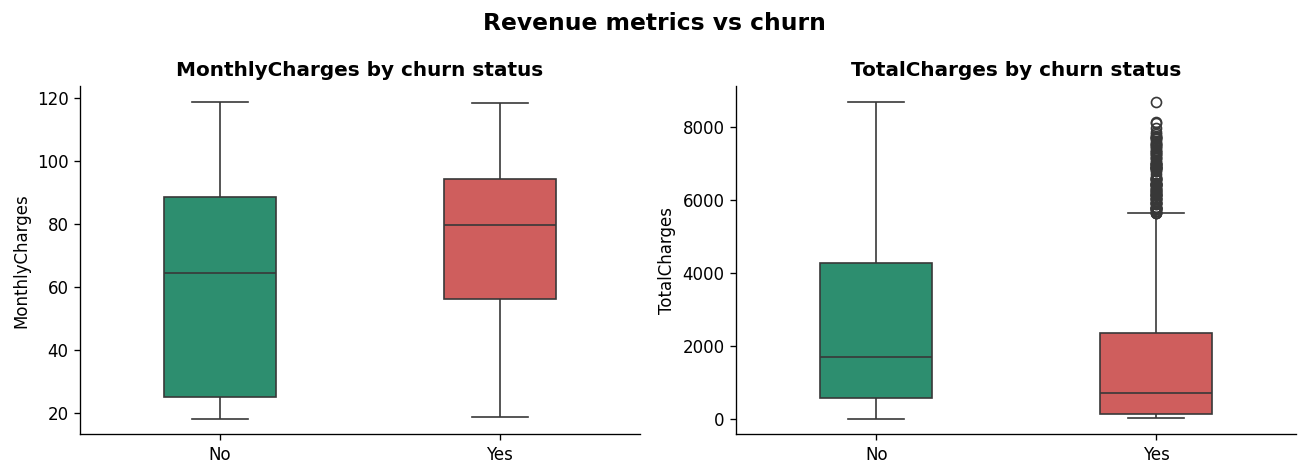

MonthlyCharges — Churned: ₹74.44 | Retained: ₹61.27
TotalCharges — Churned: ₹1531.80 | Retained: ₹2549.91


In [14]:
import os
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, col in zip(axes, ['MonthlyCharges', 'TotalCharges']):
    sns.boxplot(data=df, x='Churn', y=col, palette=CHURN_PALETTE, ax=ax,
                width=0.4, linewidth=1)
    ax.set_title(f'{col} by churn status', fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Revenue metrics vs churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('visuals/06_charges_churn.png', bbox_inches='tight')
plt.show()

for col in ['MonthlyCharges', 'TotalCharges']:
    churned = df[df['Churn']=='Yes'][col].mean()
    retained = df[df['Churn']=='No'][col].mean()
    print(f"{col} — Churned: ₹{churned:.2f} | Retained: ₹{retained:.2f}")

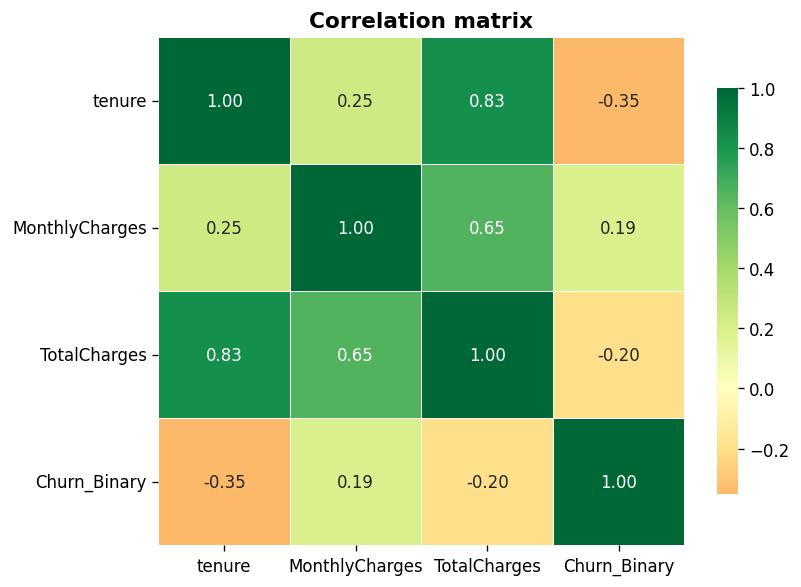

In [15]:
import os
fig, ax = plt.subplots(figsize=(7, 5))

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_Binary']
corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation matrix', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('visuals/07_correlation_heatmap.png', bbox_inches='tight')
plt.show()

In [17]:
summary = df.groupby('Churn')['tenure'].agg(['mean','median']).round(1)
print("=== Top churn risk factors discovered ===\n")
print("1. Contract type: Month-to-month customers churn 4x more than annual")
print("2. Tenure: Churned avg tenure =", round(df[df['Churn']=='Yes']['tenure'].mean(),1), "months")
print("3. Senior citizens: ~42% churn rate vs ~24% for others")
print("4. No partner/dependents: higher churn in single users")
print("5. Fiber optic + electronic check: highest churn combo")
print("6. Auto-pay customers: significantly lower churn")
print("\nTotal visuals saved to visuals/ folder:", 7)

=== Top churn risk factors discovered ===

1. Contract type: Month-to-month customers churn 4x more than annual
2. Tenure: Churned avg tenure = 18.0 months
3. Senior citizens: ~42% churn rate vs ~24% for others
4. No partner/dependents: higher churn in single users
5. Fiber optic + electronic check: highest churn combo
6. Auto-pay customers: significantly lower churn

Total visuals saved to visuals/ folder: 7
